<a id="top"></a>
# PQR Market Intelligence Lab
## Explainable procurement-price benchmarking and market-resilience signals

**Portfolio edition · Global Fund Price & Quality Reporting data · 2003–2026**

> **Decision purpose.** Help procurement and market-shaping teams distinguish explainable price variation from transactions that warrant review—while monitoring supplier concentration, price dispersion and data quality.

This is a decision-support analysis, **not** an audit, fraud detector or causal assessment. PQR data are reported by Principal Recipients and other parties and remain subject to the official Global Fund caveats included with the project.

### Navigation

1. [Executive brief](#executive)
2. [Data and governance](#data)
3. [Market landscape](#market)
4. [Supplier resilience](#resilience)
5. [Price dispersion](#dispersion)
6. [Machine-learning design](#ml)
7. [Untouched test evaluation](#evaluation)
8. [Explainability and review signals](#signals)
9. [Decision playbook](#playbook)
10. [Key takeaways for GF and partners](#takeaways)
11. [Limitations and reproducibility](#limits)


In [1]:
# UI, imports and deterministic configuration
from pathlib import Path
from IPython.display import display, HTML, Markdown
import json, re, warnings, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize':(12,5.5),'axes.titleweight':'bold','axes.titlesize':15,'axes.labelsize':11})

display(HTML("""
<style>
:root{--navy:#102A43;--blue:#1565C0;--cyan:#00A6A6;--gold:#F2B134;--red:#D64545;--ink:#243B53;--soft:#F4F8FB}
.jp-Notebook,.notebook-container{max-width:1280px!important;margin:auto!important}
h1{color:var(--navy)!important;border-bottom:5px solid var(--cyan);padding-bottom:12px}
h2{color:var(--navy)!important;margin-top:40px!important;border-left:7px solid var(--gold);padding-left:12px}
h3{color:var(--blue)!important}.alert{padding:16px 20px;border-radius:12px;margin:14px 0;background:#FFF8E1;border-left:6px solid var(--gold)}
.method{padding:16px 20px;border-radius:12px;background:#E8F4FD;border-left:6px solid var(--blue)}
.guard{padding:16px 20px;border-radius:12px;background:#EAF7F4;border-left:6px solid var(--cyan)}
.cards{display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin:18px 0}.card{background:white;border:1px solid #D9E2EC;border-radius:14px;padding:18px;box-shadow:0 4px 14px rgba(16,42,67,.08)}
.card .k{font-size:12px;text-transform:uppercase;color:#627D98;font-weight:700}.card .v{font-size:28px;color:var(--navy);font-weight:800;margin-top:5px}.card .s{font-size:12px;color:#829AB1;margin-top:4px}
table{font-size:13px}.dataframe thead th{background:var(--navy)!important;color:white!important}.dataframe tbody tr:nth-child(even){background:#F4F8FB}
.pill{display:inline-block;padding:4px 10px;border-radius:20px;background:#D9EAF7;color:var(--navy);font-weight:700;margin:2px}
@media(max-width:800px){.cards{grid-template-columns:repeat(2,1fr)}}
</style>"""))
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn loaded | seed={SEED}')

Python 3.12.14 | pandas 2.2.3 | scikit-learn loaded | seed=42


<a id="takeaways"></a>
## 10. Key takeaways for the Global Fund and partners

> **Strategic conclusion.** PQR can support a practical market-intelligence and early-warning capability—not simply retrospective price reporting. Its strongest use is to combine like-for-like price benchmarking, procurement context and supplier-resilience signals to focus expert review where it is most valuable.

### Results that matter for decision-makers

| Finding from this analysis | Evidence from the current run | Implication for GF and partners |
|---|---:|---|
| Like-for-like comparability is fundamental | Product and product-pack were the two most influential model features; standardized pack units ranked third | Price comparisons should first align product, formulation/presentation, pack, quantity, currency and freight treatment |
| Context adjustment improves benchmarking | Context-model log-MAE was **0.399**, versus **0.471** for the product-pack median baseline—a **15.3% reduction** in error | A contextual benchmark can prioritize review more accurately than a single global median |
| Manufacturer identity contains additional market information | Manufacturer-adjusted log-MAE was **0.372**, a **21.0% reduction** versus the baseline; median absolute percentage error fell from **25.2% to 21.0%** | Supplier and market structure should be considered alongside price, without interpreting manufacturer effects causally |
| A targeted queue is feasible | **48 of 3,629** untouched 2024–2025 test transactions met both conservative high-price criteria (**1.32%**) | Expert attention can focus on a small number of records instead of labelling whole countries, suppliers or portfolios |
| Diagnostics merit focused comparability work | **22 of 48** review signals were diagnostics, PPE or medical devices; anti-TB medicines accounted for **13** | Review proprietary platforms, instrument–reagent dependencies, specifications, order size, eligibility and delivery conditions before drawing conclusions |
| Supply resilience is a material concern | Of **101** recent product-pack markets assessed, **53** had one reported manufacturer; **47 of 48** multi-manufacturer markets met the analysis's high-concentration threshold | Pair value-for-money monitoring with qualified-supplier diversity, availability, lead time and continuity-of-supply indicators |
| The source data are arithmetically strong where complete, but analytical readiness can improve | **93,833 of 93,838** complete numeric records reconciled within 1%; **43,054 of 93,840** source transactions met the strict modelling criteria | Prioritize stable product/pack and supplier identifiers, structured freight terms, quality status, lead times and reasons for exceptional procurement |

*Error reduction is calculated as `(baseline log-MAE − model log-MAE) / baseline log-MAE`. The alert share is `48 / 3,629 × 100 = 1.32%`. Concentration is based on reported product-cost shares within narrowly defined product-pack markets and is sensitive to manufacturer-name harmonization.*

### Recommended operational application

A quarterly **PQR Market Intelligence Review Queue** could give reviewers an expected price range, observed-to-expected ratio, manufacturer-adjusted sensitivity result, comparability warnings, concentration indicator and relevant historical comparators. Each reviewed signal should receive a disposition such as specification mismatch, freight difference, emergency purchase, valid premium, data correction, limited competition or further review required. Those adjudications could improve future models and institutional learning.

### Interpretation boundary

A review signal is **not evidence of overpricing, misconduct or achievable savings**. The public PQR fields do not capture every quality requirement, tender condition, local registration constraint, lead time, market shortage or emergency circumstance. These results should therefore prompt structured professional review and constructive engagement—not automated procurement decisions.

**Stakeholder-ready message:** *PQR already contains enough information to support context-adjusted benchmarking and targeted market monitoring. The opportunity is to integrate price, comparability and supplier-resilience evidence so that GF and partners can identify where explanation, data validation or market-shaping action would be most valuable.*

[Back to top](#top)


<a id="data"></a>
## 1. Data, provenance and governance

The notebook searches recursively for the required files, which makes it usable in Google Drive, Colab uploads and a local clone. Keep raw exports unchanged; transformations are written only to `outputs/`.

**Required:** `pqr_transactions_2003_2026_ml_ready.csv`  
**Recommended enrichment:** World Bank country metadata, WHO prequalified finished products, current PQR medicines and diagnostics price-reference exports, and the official PQR caveats PDF.


In [2]:
# Colab/Drive path configuration
USE_GOOGLE_DRIVE = False  # Set True in Colab when files are stored in Drive
DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/global-health-market-access')
PROJECT_ROOT_OVERRIDE = None  # e.g. Path('/content/drive/MyDrive/global-health-market-access')

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

def choose_root():
    candidates=[]
    if PROJECT_ROOT_OVERRIDE: candidates.append(Path(PROJECT_ROOT_OVERRIDE))
    if USE_GOOGLE_DRIVE: candidates.append(DRIVE_PROJECT_ROOT)
    candidates += [Path.cwd(), Path('/content')]
    for root in candidates:
        if root.exists() and list(root.rglob('pqr_transactions_2003_2026_ml_ready.csv')):
            return root
    raise FileNotFoundError('Required ML-ready PQR CSV not found. See the reproducibility section for the exact folder layout.')

PROJECT_ROOT=choose_root()
OUTPUT_DIR=PROJECT_ROOT/'outputs'/'pqr_market_intelligence'
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

def find_one(name, required=False):
    hits=list(PROJECT_ROOT.rglob(name))
    if not hits and required: raise FileNotFoundError(name)
    return hits[0] if hits else None

paths={
 'pqr':find_one('pqr_transactions_2003_2026_ml_ready.csv',True),
 'wb':find_one('world_bank_country_metadata.json'),
 'who_pq':find_one('who_prequalified_finished_products.csv'),
 'med_ref':find_one('pqr_current_medicines_by_country.csv'),
 'diag_ref':find_one('pqr_current_diagnostics_by_country.csv'),
 'caveats':find_one('psm_pqrdatacaveats_note_en.pdf')}
display(pd.DataFrame({'asset':paths.keys(),'resolved_path':[str(v) if v else 'optional—not found' for v in paths.values()]}))

,asset,resolved_path
0,pqr,/workspace/scratch/40625a1063a8/project1_pqr_u...
1,wb,/workspace/scratch/40625a1063a8/project1_downl...
2,who_pq,/workspace/scratch/40625a1063a8/project1_downl...
3,med_ref,/workspace/scratch/40625a1063a8/project1_pqr_u...
4,diag_ref,/workspace/scratch/40625a1063a8/project1_pqr_u...
5,caveats,/workspace/scratch/40625a1063a8/project1_pqr_u...


In [3]:
# Load the transaction table and preserve a source snapshot
raw=pd.read_csv(paths['pqr'],low_memory=False)
raw.columns=[c.strip().lower() for c in raw.columns]
df=raw.copy()

date_cols=['purchase_order_date','scheduled_delivery_date','actual_delivery_date']
for c in date_cols:
    if c in df: df[c]=pd.to_datetime(df[c],errors='coerce')
for c in ['pack_quantity','product_pack_usd','total_product_cost_usd','nb_of_suom_in_pack']:
    if c in df: df[c]=pd.to_numeric(df[c],errors='coerce')

df['order_year']=df.purchase_order_date.dt.year
df['order_month']=df.purchase_order_date.dt.month
df['log_pack_quantity']=np.log1p(df.pack_quantity.clip(lower=0))
df['price_positive']=df.product_pack_usd.gt(0)
df['cost_reconciliation_ratio']=df.total_product_cost_usd/(df.pack_quantity*df.product_pack_usd).replace(0,np.nan)
df['cost_reconciles_1pct']=(df.cost_reconciliation_ratio-1).abs().le(.01)

qa=pd.DataFrame({
 'metric':['Rows received','Unique primary keys','Valid positive prices','Missing purchase dates','Cost records reconciling within 1%','2026 rows (partial year)'],
 'value':[len(df),df.primary_key.nunique(),df.price_positive.sum(),df.purchase_order_date.isna().sum(),df.cost_reconciles_1pct.sum(),df.order_year.eq(2026).sum()]})
display(qa.style.format({'value':'{:,.0f}'}))

,metric,value
0,Rows received,"93,840"
1,Unique primary keys,"93,840"
2,Valid positive prices,"92,074"
3,Missing purchase dates,0
4,Cost records reconciling within 1%,"15,111"
5,2026 rows (partial year),268


In [4]:
# Optional World Bank enrichment
df['wb_region']='Unmatched'; df['wb_income']='Unmatched'
if paths['wb']:
    payload=json.load(open(paths['wb'],encoding='utf-8'))
    records=payload[1] if isinstance(payload,list) and len(payload)>1 else []
    wb=pd.DataFrame([{'country':r.get('name'),'iso3':r.get('id'),
                      'wb_region':(r.get('region') or {}).get('value'),
                      'wb_income':(r.get('incomeLevel') or {}).get('value')} for r in records])
    aliases={'Russian Federation':'Russia','Tanzania (United Republic)':'Tanzania','Congo (Democratic Republic)':'Congo, Dem. Rep.',
             'Congo':'Congo, Rep.','Côte d’Ivoire':"Cote d'Ivoire",'Côte d\'Ivoire':"Cote d'Ivoire",'Viet Nam':'Vietnam',
             'Iran (Islamic Republic)':'Iran, Islamic Rep.','Lao (Peoples Democratic Republic)':'Lao PDR','Kyrgyzstan':'Kyrgyz Republic',
             'Egypt':'Egypt, Arab Rep.','Yemen':'Yemen, Rep.','Slovakia':'Slovak Republic'}
    df['_wb_name']=df.country_teritorry.replace(aliases)
    df=df.drop(columns=['wb_region','wb_income']).merge(wb[['country','wb_region','wb_income']],left_on='_wb_name',right_on='country',how='left')
    df[['wb_region','wb_income']]=df[['wb_region','wb_income']].fillna('Unmatched')
print(f"World Bank income match: {(df.wb_income!='Unmatched').mean():.1%}")

World Bank income match: 90.8%


<div class="guard"><b>Governance rule:</b> identifiers, invoice numbers, actual delivery dates, scheduled delivery dates and total cost are excluded from price prediction. Total cost is mathematically downstream of pack price and quantity; including it would create target leakage.</div>

<a id="executive"></a>
## 2. Executive brief


In [5]:
# Portfolio snapshot (complete years shown separately from 2026 YTD)
complete=df[df.order_year.between(2003,2025) & df.price_positive].copy()
spend=complete.total_product_cost_usd.sum(min_count=1)
latest=complete.order_year.max()
cards=f"""<div class="cards">
<div class="card"><div class="k">Transactions</div><div class="v">{len(complete):,.0f}</div><div class="s">positive-price records, 2003–{latest}</div></div>
<div class="card"><div class="k">Reported product cost</div><div class="v">${spend/1e9:,.2f}B</div><div class="s">not total landed procurement cost</div></div>
<div class="card"><div class="k">Markets represented</div><div class="v">{complete.country_teritorry.nunique():,.0f}</div><div class="s">countries/territories</div></div>
<div class="card"><div class="k">Manufacturers</div><div class="v">{complete.manufacturer.nunique():,.0f}</div><div class="s">before entity harmonization</div></div>
</div>"""
display(HTML(cards))

latest_df=complete[complete.order_year==latest]
headline=pd.DataFrame({
 'question':['Where is spend concentrated?','Is the supply base diversified?','How variable are like-for-like prices?','What does ML add?'],
 'indicator':[latest_df.groupby('product_category').total_product_cost_usd.sum().idxmax(),
              f"{latest_df.manufacturer.nunique():,} reported manufacturers",
              'Quantified below for product-pack markets with ≥10 transactions',
              'Context-adjusted expected prices and review signals—never automatic allegations']})
display(headline.style.hide(axis='index'))

question,indicator
Where is spend concentrated?,Anti-TB medicine
Is the supply base diversified?,106 reported manufacturers
How variable are like-for-like prices?,Quantified below for product-pack markets with ≥10 transactions
What does ML add?,Context-adjusted expected prices and review signals—never automatic allegations


<a id="market"></a>
## 3. Market landscape

Annual values are based on purchase-order year. The 2026 partial year is shown separately and excluded from full-year trend conclusions and model testing.


,transactions,spend,countries
product_category,,,
Anti-Retroviral and COVID-19 medicine,"39,824","$3,062,964",116
Anti-TB medicine,"21,973","$1,420,380",106
"Diagnostic, PPE and Medical Device","16,018","$975,373",131
Anti-malaria medicine,"8,410","$244,884",78
Condom,"2,558","$124,067",117
Vector Control Products,"3,025",$111,83


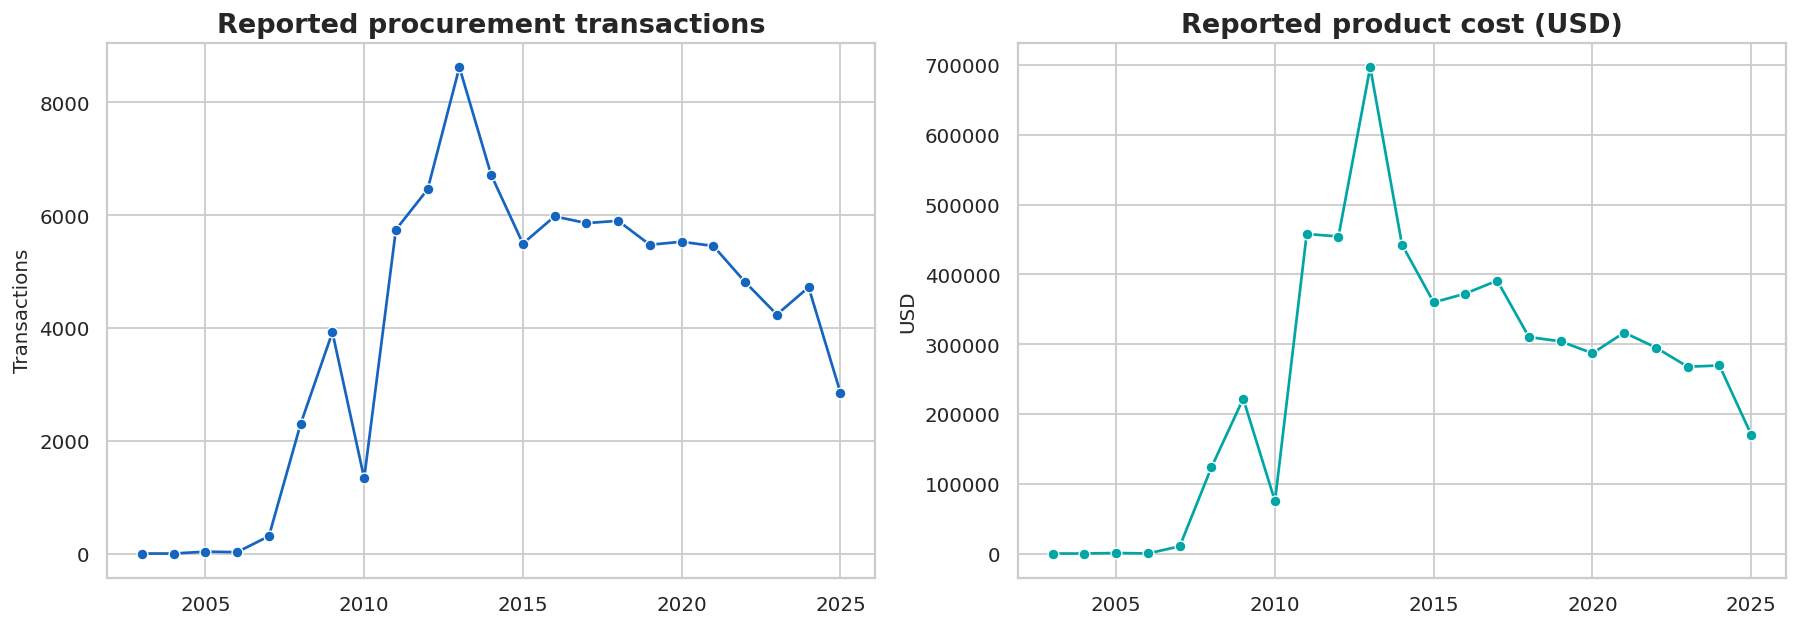

In [6]:
annual=(complete.groupby('order_year').agg(transactions=('primary_key','nunique'),
          reported_product_cost=('total_product_cost_usd','sum'),countries=('country_teritorry','nunique')).reset_index())
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=annual,x='order_year',y='transactions',marker='o',color='#1565C0',ax=ax[0]); ax[0].set(title='Reported procurement transactions',xlabel='',ylabel='Transactions')
sns.lineplot(data=annual,x='order_year',y='reported_product_cost',marker='o',color='#00A6A6',ax=ax[1]); ax[1].set(title='Reported product cost (USD)',xlabel='',ylabel='USD'); ax[1].ticklabel_format(axis='y',style='plain')
plt.tight_layout(); plt.show()

category=(complete.groupby('product_category').agg(transactions=('primary_key','nunique'),spend=('total_product_cost_usd','sum'),countries=('country_teritorry','nunique')).sort_values('spend',ascending=False))
display(category.style.format({'transactions':'{:,.0f}','spend':'${:,.0f}','countries':'{:,.0f}'}).background_gradient(subset=['spend'],cmap='Blues'))

<a id="resilience"></a>
## 4. Supplier resilience and market concentration

Concentration is calculated from manufacturer shares of reported product cost. HHI is descriptive, not a procurement verdict. Thresholds below are conventional screening bands and should be interpreted alongside product quality, eligible-supplier constraints and market size.


In [7]:
def hhi_table(data,group_cols):
    g=(data.dropna(subset=['manufacturer','total_product_cost_usd']).groupby(group_cols+['manufacturer'],dropna=False)
       .total_product_cost_usd.sum().rename('manufacturer_spend').reset_index())
    g['share']=g.manufacturer_spend/g.groupby(group_cols).manufacturer_spend.transform('sum')
    out=g.groupby(group_cols).agg(hhi=('share',lambda x:float((x*x).sum())),manufacturers=('manufacturer','nunique'),top_manufacturer_share=('share','max'),market_spend=('manufacturer_spend','sum')).reset_index()
    out['concentration_band']=pd.cut(out.hhi,[-.001,.15,.25,1.001],labels=['Lower','Moderate','High'])
    return out.sort_values(['hhi','market_spend'],ascending=[False,False])

recent=complete[complete.order_year.between(max(2003,latest-2),latest)]
cat_hhi=hhi_table(recent,['product_category'])
display(cat_hhi.style.format({'hhi':'{:.3f}','top_manufacturer_share':'{:.1%}','market_spend':'${:,.0f}'}).hide(axis='index'))

prod_hhi=hhi_table(recent,['product','product_pack'])
prod_hhi=prod_hhi[prod_hhi.market_spend>=prod_hhi.market_spend.quantile(.50)]
display(prod_hhi.head(20).style.format({'hhi':'{:.3f}','top_manufacturer_share':'{:.1%}','market_spend':'${:,.0f}'}).hide(axis='index'))

product_category,hhi,manufacturers,top_manufacturer_share,market_spend,concentration_band
Condom,0.245,9,43.6%,"$11,790",Moderate
Anti-TB medicine,0.227,13,41.8%,"$293,127",Moderate
Anti-Retroviral and COVID-19 medicine,0.191,17,37.8%,"$153,545",Moderate
Anti-malaria medicine,0.185,12,29.7%,"$37,911",Moderate
"Diagnostic, PPE and Medical Device",0.117,37,22.3%,"$205,704",Lower


product,product_pack,hhi,manufacturers,top_manufacturer_share,market_spend,concentration_band
TB molecular diagnostics,96 tests,1.000,1,100.0%,"$29,746",High
Pyrazinamide,Blister-672,1.000,1,100.0%,"$23,150",High
Isoniazid,Blister-672,1.000,1,100.0%,"$21,412",High
Bedaquiline,Bottle - 60,1.000,1,100.0%,"$15,012",High
Isoniazid+Pyrazinamide+Rifampicin - FDC,Blister-84,1.000,1,100.0%,"$10,483",High
Pyrazinamide,Box of 100 tab(10 Strips of 10 tab),1.000,1,100.0%,"$10,210",High
Ethambutol,Blister-100 (10*10),1.000,1,100.0%,"$8,543",High
Amoxicillin+Clavulanate - FDC,Blister-100,1.000,1,100.0%,"$7,697",High
Levofloxacin,Blister-100 (10*10),1.000,1,100.0%,"$7,071",High
Ethionamide,Blister-100 (10*10),1.000,1,100.0%,"$6,184",High


<a id="dispersion"></a>
## 5. Like-for-like price dispersion

Markets are defined as product × pack. Median, interquartile range and robust dispersion are preferable to raw averages when prices are skewed. The table screens markets with at least 10 transactions; it does not assume that every remaining price difference is avoidable.


In [8]:
market=(recent.groupby(['product','product_pack']).product_pack_usd.agg(['count','median',lambda x:x.quantile(.25),lambda x:x.quantile(.75),'min','max']).reset_index())
market.columns=['product','product_pack','n','median_price','q25','q75','min_price','max_price']
market=market[market.n>=10].copy()
market['iqr_ratio']=market.q75/market.q25.replace(0,np.nan)
market['max_median_ratio']=market.max_price/market.median_price.replace(0,np.nan)
market=market.sort_values(['iqr_ratio','n'],ascending=[False,False])
display(market.head(25).style.format({'median_price':'${:,.4f}','q25':'${:,.4f}','q75':'${:,.4f}','min_price':'${:,.4f}','max_price':'${:,.4f}','iqr_ratio':'{:.2f}×','max_median_ratio':'{:.2f}×'}).hide(axis='index'))

product,product_pack,n,median_price,q25,q75,min_price,max_price,iqr_ratio,max_median_ratio
TB molecular diagnostics,96 tests,120,$796.4293,$63.3499,$879.1214,$2.0000,$990.0000,13.88×,1.24×
G6PD diagnostic test,1 unit / test,16,$50.4400,$41.7675,$314.5000,$0.0377,$380.0000,7.53×,7.53×
Ethambutol,Blister-100,36,$3.8500,$3.5800,$18.3600,$3.5800,$34.1700,5.13×,8.88×
Levofloxacin,Blister-100 (10*10),72,$12.4100,$2.7500,$12.4100,$2.6100,$12.4100,4.51×,1.00×
Yorkool LN,Other,10,$1.9360,$1.6960,$6.9325,$1.4000,$10.5000,4.09×,5.42×
TB testing consumables/test kits,1000 tests,33,$83.5000,$83.5000,$323.0000,$83.4838,$435.0000,3.87×,5.21×
Male Latex Condom,,285,$0.0315,$0.0275,$0.1058,$0.0218,$21.5000,3.85×,682.54×
HIV RDT and EIA,100 Units per pack,13,$197.8176,$90.0000,$325.0000,$46.6613,$475.0000,3.61×,2.40×
TB molecular diagnostics,1 unit / test,38,$162.5000,$149.0000,$499.0000,$55.7640,$975.0000,3.35×,6.00×
HIV RDT and EIA,1 unit / test,90,$2.9988,$2.0800,$6.6394,$0.5345,$120.9849,3.19×,40.35×


<a id="ml"></a>
## 6. Machine-learning design and leakage controls

### Prediction target

`log(product_pack_usd)`. Log transformation limits the influence of extreme prices and makes residual ratios interpretable.

### Time split

- **Training:** 2003–2022
- **Validation/model selection:** 2023
- **Untouched test:** 2024–2025
- **Excluded:** 2026, because it is incomplete

### Dual-model safeguard

1. **Context model:** product, pack, category, country, income/region, volume, timing and commercial terms—but no manufacturer identity.
2. **Manufacturer-adjusted sensitivity model:** adds manufacturer. A high-price review signal is considered robust only when both models place it above their validation-derived upper interval.

This prevents one modelling choice from determining the signal and shows whether a premium persists after accounting for reported manufacturer.


In [9]:
# Analytic cohort
model_df=df[df.price_positive & df.pack_quantity.gt(0) & df.order_year.between(2003,2025)].copy()
model_df=model_df[model_df['product'].notna() & model_df.product_pack.notna() & model_df.country_teritorry.notna()]
model_df['y_log_price']=np.log(model_df.product_pack_usd)

numeric=['log_pack_quantity','order_year','order_month','nb_of_suom_in_pack']
context_cat=['product','product_pack','product_category','country_teritorry','wb_region','wb_income','freight_cost','invoice_currency_name','some_or_all_of_goods_prepaid']
sensitivity_cat=context_cat+['manufacturer']
for c in numeric+list(set(sensitivity_cat)):
    if c not in model_df: model_df[c]=np.nan

train=model_df[model_df.order_year<=2022].copy()
valid=model_df[model_df.order_year==2023].copy()
test=model_df[model_df.order_year.between(2024,2025)].copy()
display(pd.DataFrame({'split':['Train','Validation','Untouched test'],'years':['2003–2022','2023','2024–2025'],'rows':[len(train),len(valid),len(test)]}).style.hide(axis='index'))

def make_pipeline(cat_cols,params):
    pre=ColumnTransformer([
      ('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),numeric),
      ('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',TargetEncoder(random_state=SEED,smooth='auto'))]),cat_cols)
    ],verbose_feature_names_out=False)
    model=HistGradientBoostingRegressor(random_state=SEED,early_stopping=True,validation_fraction=.12,**params)
    return Pipeline([('pre',pre),('model',model)])

grid=[
 {'learning_rate':.07,'max_iter':220,'max_leaf_nodes':31,'min_samples_leaf':40,'l2_regularization':1.0},
 {'learning_rate':.05,'max_iter':300,'max_leaf_nodes':31,'min_samples_leaf':60,'l2_regularization':2.0},
 {'learning_rate':.06,'max_iter':260,'max_leaf_nodes':63,'min_samples_leaf':60,'l2_regularization':3.0}]

selection=[]
for i,p in enumerate(grid,1):
    pipe=make_pipeline(context_cat,p)
    pipe.fit(train[numeric+context_cat],train.y_log_price)
    pv=pipe.predict(valid[numeric+context_cat])
    selection.append({'candidate':i,'log_MAE':mean_absolute_error(valid.y_log_price,pv),'parameters':p,'pipeline':pipe})
sel_table=pd.DataFrame([{k:v for k,v in x.items() if k!='pipeline'} for x in selection]).sort_values('log_MAE')
display(sel_table.style.format({'log_MAE':'{:.4f}'}).hide(axis='index'))
best_params=selection[int(np.argmin([x['log_MAE'] for x in selection]))]['parameters']

split,years,rows
Train,2003–2022,37352
Validation,2023,2073
Untouched test,2024–2025,3629


candidate,log_MAE,parameters
3,0.4218,"{'learning_rate': 0.06, 'max_iter': 260, 'max_leaf_nodes': 63, 'min_samples_leaf': 60, 'l2_regularization': 3.0}"
1,0.4316,"{'learning_rate': 0.07, 'max_iter': 220, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'l2_regularization': 1.0}"
2,0.4374,"{'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 60, 'l2_regularization': 2.0}"


In [10]:
# Refit using train + validation, preserving the untouched test
development=pd.concat([train,valid],ignore_index=True)
context_model=make_pipeline(context_cat,best_params).fit(development[numeric+context_cat],development.y_log_price)
sensitivity_model=make_pipeline(sensitivity_cat,best_params).fit(development[numeric+sensitivity_cat],development.y_log_price)

# Product-pack median baseline learned only from development data
median_map=development.groupby(['product','product_pack']).y_log_price.median()
global_median=development.y_log_price.median()
def baseline_predict(frame):
    idx=pd.MultiIndex.from_frame(frame[['product','product_pack']])
    return pd.Series(idx.map(median_map),index=frame.index).fillna(global_median).to_numpy(float)

pred_base=baseline_predict(test)
pred_context=context_model.predict(test[numeric+context_cat])
pred_sens=sensitivity_model.predict(test[numeric+sensitivity_cat])

def metrics(y,p,label):
    ratio=np.exp(p-y)
    ape=np.abs(np.exp(p)-np.exp(y))/np.exp(y)
    return {'model':label,'log_MAE':mean_absolute_error(y,p),'log_RMSE':mean_squared_error(y,p)**.5,
            'R2_log':r2_score(y,p),'median_APE':np.median(ape),'within_20pct':np.mean((ratio>=.8)&(ratio<=1.2)),
            'within_50pct':np.mean((ratio>=.5)&(ratio<=1.5))}
results=pd.DataFrame([metrics(test.y_log_price,pred_base,'Product-pack median baseline'),metrics(test.y_log_price,pred_context,'Context ML'),metrics(test.y_log_price,pred_sens,'Manufacturer-adjusted ML')])
display(results.style.format({'log_MAE':'{:.3f}','log_RMSE':'{:.3f}','R2_log':'{:.3f}','median_APE':'{:.1%}','within_20pct':'{:.1%}','within_50pct':'{:.1%}'}).hide(axis='index'))

model,log_MAE,log_RMSE,R2_log,median_APE,within_20pct,within_50pct
Product-pack median baseline,0.471,0.836,0.738,25.2%,42.2%,71.0%
Context ML,0.399,0.678,0.828,24.0%,44.4%,75.0%
Manufacturer-adjusted ML,0.372,0.649,0.842,21.0%,48.3%,77.2%


<a id="evaluation"></a>
## 7. Untouched test-set evaluation

The plot assesses calibration in price-ratio space. Points above the diagonal have higher observed prices than expected; this is a review cue, not proof of inefficiency.


order_year,n,median_abs_pct_error,median_ratio
2024,"2,214",23.1%,0.98×
2025,"1,415",25.1%,0.97×


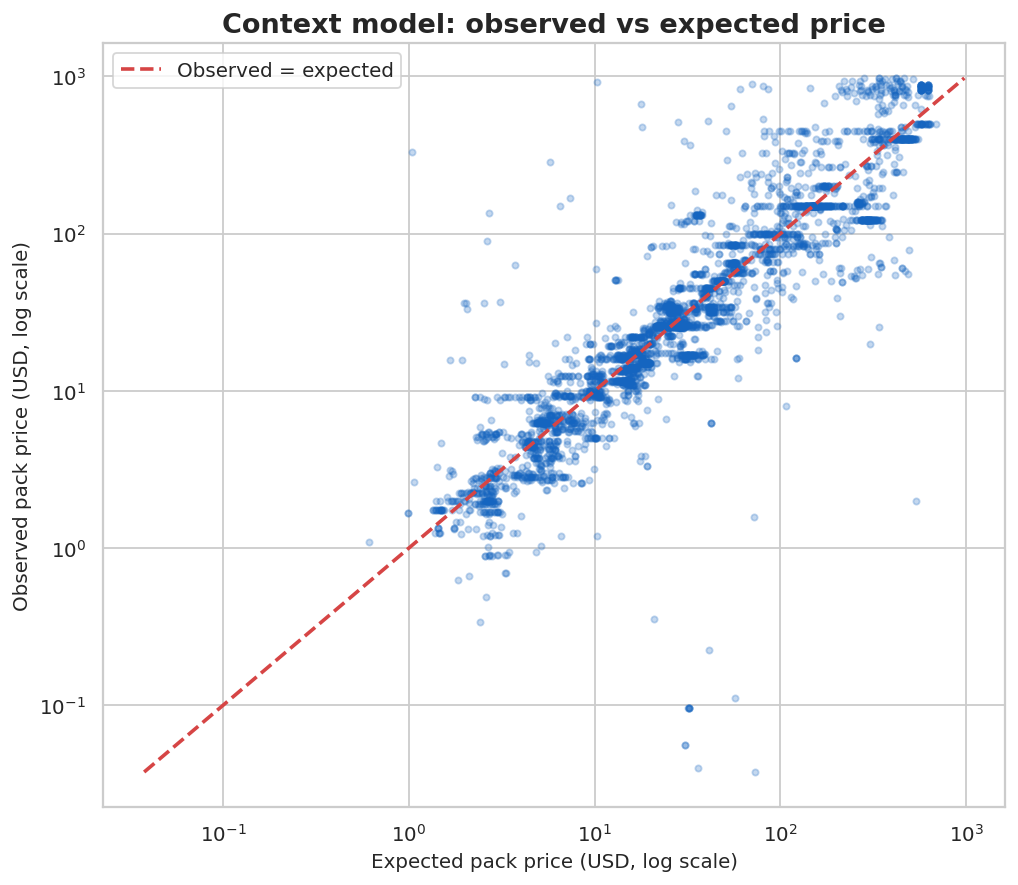

In [11]:
test_scored=test.copy()
test_scored['predicted_context_price']=np.exp(pred_context)
test_scored['predicted_manufacturer_adjusted_price']=np.exp(pred_sens)
test_scored['observed_expected_ratio_context']=test_scored.product_pack_usd/test_scored.predicted_context_price
test_scored['observed_expected_ratio_sensitivity']=test_scored.product_pack_usd/test_scored.predicted_manufacturer_adjusted_price

sample=test_scored.sample(min(6000,len(test_scored)),random_state=SEED)
fig,ax=plt.subplots(figsize=(8,7))
ax.scatter(sample.predicted_context_price,sample.product_pack_usd,s=12,alpha=.25,color='#1565C0')
lims=[max(1e-5,min(sample.predicted_context_price.min(),sample.product_pack_usd.min())),max(sample.predicted_context_price.max(),sample.product_pack_usd.max())]
ax.plot(lims,lims,'--',color='#D64545',lw=2,label='Observed = expected'); ax.set(xscale='log',yscale='log',xlabel='Expected pack price (USD, log scale)',ylabel='Observed pack price (USD, log scale)',title='Context model: observed vs expected price'); ax.legend(); plt.tight_layout(); plt.show()

by_year=test_scored.groupby('order_year').apply(lambda g:pd.Series({'n':len(g),'median_abs_pct_error':np.median(np.abs(g.product_pack_usd-g.predicted_context_price)/g.product_pack_usd),'median_ratio':g.observed_expected_ratio_context.median()}),include_groups=False).reset_index()
display(by_year.style.format({'n':'{:,.0f}','median_abs_pct_error':'{:.1%}','median_ratio':'{:.2f}×'}).hide(axis='index'))

<a id="signals"></a>
## 8. Explainability and robust review signals

Prediction intervals are derived from **2023 validation residuals**, not from the test set. A robust high review signal requires both the context and manufacturer-adjusted residual to exceed their respective upper validation thresholds. This is deliberately conservative.


In [12]:
# Validation-based empirical intervals (models fitted only through 2022 for threshold construction)
selection_model=selection[int(np.argmin([x['log_MAE'] for x in selection]))]['pipeline']
valid_context_pred=selection_model.predict(valid[numeric+context_cat])
sens_threshold_model=make_pipeline(sensitivity_cat,best_params).fit(train[numeric+sensitivity_cat],train.y_log_price)
valid_sens_pred=sens_threshold_model.predict(valid[numeric+sensitivity_cat])
lo_c,hi_c=np.quantile(valid.y_log_price-valid_context_pred,[.025,.975])
lo_s,hi_s=np.quantile(valid.y_log_price-valid_sens_pred,[.025,.975])

test_scored['residual_context']=test_scored.y_log_price-np.log(test_scored.predicted_context_price)
test_scored['residual_sensitivity']=test_scored.y_log_price-np.log(test_scored.predicted_manufacturer_adjusted_price)
test_scored['review_signal']=np.select([
 (test_scored.residual_context>hi_c)&(test_scored.residual_sensitivity>hi_s),
 (test_scored.residual_context<lo_c)&(test_scored.residual_sensitivity<lo_s)],
 ['High-price review','Low-price review'],default='Within empirical range')

signal_summary=test_scored.review_signal.value_counts().rename_axis('signal').reset_index(name='transactions')
signal_summary['share']=signal_summary.transactions/len(test_scored)
display(signal_summary.style.format({'transactions':'{:,.0f}','share':'{:.1%}'}).hide(axis='index'))

review_cols=['primary_key','purchase_order_date','country_teritorry','product_category','product','product_pack','manufacturer','pack_quantity','product_pack_usd','predicted_context_price','predicted_manufacturer_adjusted_price','observed_expected_ratio_context','observed_expected_ratio_sensitivity','freight_cost','review_signal']
review=test_scored[test_scored.review_signal=='High-price review'].sort_values('observed_expected_ratio_context',ascending=False)
display(review[review_cols].head(30).style.format({'pack_quantity':'{:,.0f}','product_pack_usd':'${:,.4f}','predicted_context_price':'${:,.4f}','predicted_manufacturer_adjusted_price':'${:,.4f}','observed_expected_ratio_context':'{:.2f}×','observed_expected_ratio_sensitivity':'{:.2f}×'}).hide(axis='index'))
review[review_cols].to_csv(OUTPUT_DIR/'high_price_review_signals_2024_2025.csv',index=False)

signal,transactions,share
Within empirical range,"3,543",97.6%
High-price review,48,1.3%
Low-price review,38,1.0%


primary_key,purchase_order_date,country_teritorry,product_category,product,product_pack,manufacturer,pack_quantity,product_pack_usd,predicted_context_price,predicted_manufacturer_adjusted_price,observed_expected_ratio_context,observed_expected_ratio_sensitivity,freight_cost,review_signal
133958,2025-02-05 00:00:00,Angola,Condom,Female Condom,,Cupid Limited,180,$330.0000,$1.0448,$1.4370,315.85×,229.65×,Reported separately,High-price review
126803,2024-02-23 00:00:00,Mongolia,Anti-TB medicine,Ethionamide,Bottle-100,Macleods Pharmaceuticals Ltd,161,$916.0000,$10.3670,$10.4155,88.36×,87.95×,Embedded in unit cost,High-price review
126508,2024-05-08 00:00:00,Djibouti,Anti-Retroviral and COVID-19 medicine,Zidovudine (AZT or ZDV),Bottle of 200 ml,Viiv Healthcare - ex Glaxo SmithKline Ltd.,32,$135.4000,$2.7185,$21.1201,49.81×,6.41×,Reported separately,High-price review
126807,2024-02-23 00:00:00,Mongolia,Anti-TB medicine,Levofloxacin,Blister-100,Medochemie,397,$284.0000,$5.7315,$5.2717,49.55×,53.87×,Embedded in unit cost,High-price review
137092,2025-02-14 00:00:00,Somalia,"Diagnostic, PPE and Medical Device",Malaria RDT: P.f.,25 tests,Bioland Ltd.,25,$666.0176,$17.8671,$44.1874,37.28×,15.07×,Reported separately,High-price review
136125,2024-09-11 00:00:00,Thailand,"Diagnostic, PPE and Medical Device",Syphilis tests,1 unit / test,Alere Medical Japan (Matsudo Japan),700,$90.0284,$2.6370,$6.2941,34.14×,14.30×,Reported separately,High-price review
135934,2025-09-29 00:00:00,Somalia,Anti-malaria medicine,Artemether+Lumefantrine - FDC,Blister-720 (30*24),Quality Chemical Industries Ltd. - QCIL (under licence from Cipla),30,$477.1036,$17.9580,$21.1236,26.57×,22.59×,Reported separately,High-price review
123561,2024-05-27 00:00:00,Russian Federation,"Diagnostic, PPE and Medical Device",Hepatitis C assays,1 unit / test,"Standard Diagnostics, Inc.Giheung-ku, Republic of Korea",450,$168.3974,$7.3950,$3.3346,22.77×,50.50×,Embedded in unit cost,High-price review
133510,2024-11-25 00:00:00,Côte d'Ivoire,Anti-malaria medicine,Dihydroartemisinin+Piperaquine - FDC,Box of 225 tablet(25 Blisters of 9 tablet),Guilin Pharmaceutical Co. Ltd-FOSUN Pharma,400,$36.3800,$1.9814,$2.0230,18.36×,17.98×,Reported separately,High-price review
137380,2025-08-21 00:00:00,Guinea-Bissau,Anti-TB medicine,Linezolid,Blister-100 (10*10),Macleods Pharmaceuticals Ltd,2,$516.9500,$28.2682,$33.7932,18.29×,15.30×,Reported separately,High-price review


feature,importance,sd
product,0.8285,0.0064
product_pack,0.4750,0.0014
nb_of_suom_in_pack,0.0959,0.0005
invoice_currency_name,0.0563,0.0006
log_pack_quantity,0.0285,0.0002
product_category,0.0225,0.0004
country_teritorry,0.0141,0.0012
wb_region,0.0061,0.0017
freight_cost,0.0051,0.0001
some_or_all_of_goods_prepaid,0.0029,0.0004


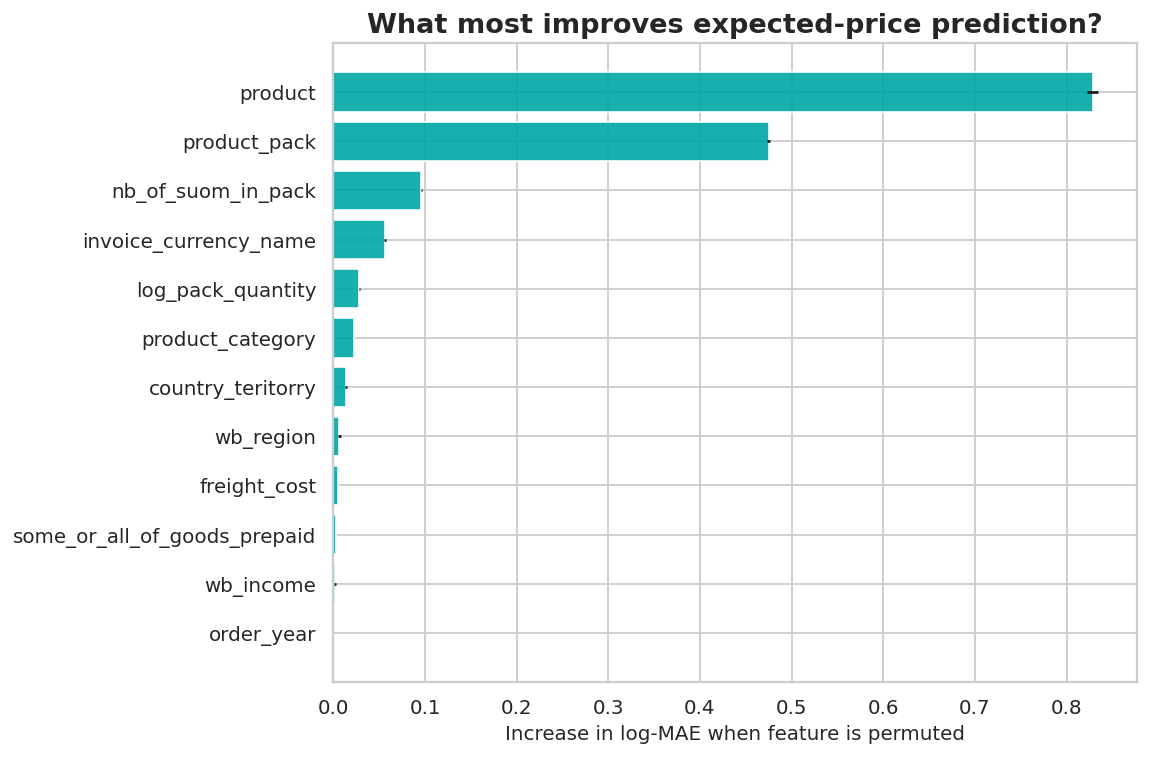

In [13]:
# Model-agnostic permutation importance on an untouched test sample
imp_sample=test.sample(min(2500,len(test)),random_state=SEED)
pi=permutation_importance(context_model,imp_sample[numeric+context_cat],imp_sample.y_log_price,n_repeats=3,random_state=SEED,scoring='neg_mean_absolute_error',n_jobs=1)
importance=pd.DataFrame({'feature':numeric+context_cat,'importance':pi.importances_mean,'sd':pi.importances_std}).sort_values('importance',ascending=False)
fig,ax=plt.subplots(figsize=(9,6)); top=importance.head(12).sort_values('importance'); ax.barh(top.feature,top.importance,xerr=top.sd,color='#00A6A6',alpha=.9); ax.set(title='What most improves expected-price prediction?',xlabel='Increase in log-MAE when feature is permuted'); plt.tight_layout(); plt.show()
display(importance.head(15).style.format({'importance':'{:.4f}','sd':'{:.4f}'}).hide(axis='index'))

In [14]:
# Country-product monitoring summary
monitor=(test_scored.groupby(['country_teritorry','product_category']).agg(
    transactions=('primary_key','nunique'),reported_product_cost=('total_product_cost_usd','sum'),
    median_observed_expected_ratio=('observed_expected_ratio_context','median'),
    high_review_signals=('review_signal',lambda x:(x=='High-price review').sum()),
    manufacturers=('manufacturer','nunique')).reset_index())
monitor['high_review_share']=monitor.high_review_signals/monitor.transactions
monitor=monitor[monitor.transactions>=10].sort_values(['high_review_share','transactions'],ascending=[False,False])
display(monitor.head(30).style.format({'transactions':'{:,.0f}','reported_product_cost':'${:,.0f}','median_observed_expected_ratio':'{:.2f}×','high_review_signals':'{:,.0f}','manufacturers':'{:,.0f}','high_review_share':'{:.1%}'}).hide(axis='index'))
monitor.to_csv(OUTPUT_DIR/'country_product_monitoring_2024_2025.csv',index=False)
prod_hhi.to_csv(OUTPUT_DIR/'manufacturer_concentration_recent.csv',index=False)
results.to_csv(OUTPUT_DIR/'model_test_metrics.csv',index=False)
importance.to_csv(OUTPUT_DIR/'permutation_importance.csv',index=False)

country_teritorry,product_category,transactions,reported_product_cost,median_observed_expected_ratio,high_review_signals,manufacturers,high_review_share
South Africa,Anti-TB medicine,27,$957,0.60×,5,3,18.5%
Venezuela (Bolivarian Republic),Anti-Retroviral and COVID-19 medicine,17,"$3,171",0.91×,3,6,17.6%
Congo,"Diagnostic, PPE and Medical Device",15,$0,1.98×,2,4,13.3%
Somalia,"Diagnostic, PPE and Medical Device",29,$440,1.05×,3,7,10.3%
Azerbaijan,"Diagnostic, PPE and Medical Device",21,"$2,560",0.93×,2,6,9.5%
Burkina Faso,"Diagnostic, PPE and Medical Device",22,"$2,271",0.97×,2,8,9.1%
Guinea-Bissau,Anti-TB medicine,22,"$1,039",1.25×,2,6,9.1%
Kosovo,"Diagnostic, PPE and Medical Device",11,$0,1.25×,1,5,9.1%
Moldova,"Diagnostic, PPE and Medical Device",44,"$6,682",0.89×,3,5,6.8%
Gambia,Anti-malaria medicine,30,"$1,883",0.74×,2,4,6.7%


<a id="playbook"></a>
## 9. Decision playbook

| Signal | Appropriate next question | Do not conclude |
|---|---|---|
| High observed/expected ratio in both models | Are pack, freight, delivery urgency, quality status, payment terms and order size genuinely comparable? | “The transaction was overpriced.” |
| High manufacturer concentration | Are sufficient quality-assured alternatives eligible, registered and available? | “The manufacturer is anti-competitive.” |
| High within-market dispersion | Does heterogeneity remain after stratifying by product presentation, freight and time? | “Every purchaser could achieve the minimum price.” |
| Low-price review signal | Is the record correct, quality-assured and comparable, and can the procurement practice be learned from? | “This is automatically the best-value transaction.” |

### Recommended operational sequence

1. **Validate the record** against source documentation.
2. **Confirm comparability** of product, pack, quality status, freight and purchasing terms.
3. **Benchmark the market** using recent comparable transactions—not the global minimum.
4. **Assess resilience**: eligible manufacturers, lead times and concentration.
5. **Engage constructively** with procurement teams and suppliers.
6. **Record the disposition** of every alert so future models learn from reviewed outcomes.


<a id="limits"></a>
## 11. Limitations, ethics and reproducibility

- PQR is self-reported and may be incomplete or revised.
- Product pack price is not necessarily the total landed cost.
- Public fields do not capture every tender condition, lead time, local registration constraint, quality requirement or emergency circumstance.
- The model estimates association, not causal savings.
- Manufacturer names require entity resolution; concentration estimates may split the same company across spellings.
- Empirical intervals reflect 2023 residuals and may not guarantee future statistical coverage under market shifts.
- 2026 is partial and excluded from full-year model evaluation.
- Review signals should be assessed by qualified procurement and market-shaping professionals.

### Re-run assurance

The next cell writes a machine-readable run manifest with source path, row counts, model parameters, thresholds and software versions.


In [15]:
manifest={
 'run_timestamp_utc':pd.Timestamp.utcnow().isoformat(), 'random_seed':SEED,
 'source_file':str(paths['pqr']), 'source_rows':len(raw), 'analytic_rows':len(model_df),
 'splits':{'train_through':2022,'validation':2023,'test':[2024,2025],'excluded_partial_year':2026},
 'best_model_parameters':best_params,
 'validation_residual_thresholds':{'context_2_5pct':float(lo_c),'context_97_5pct':float(hi_c),'sensitivity_2_5pct':float(lo_s),'sensitivity_97_5pct':float(hi_s)},
 'software':{'python':platform.python_version(),'pandas':pd.__version__},
 'output_files':sorted([p.name for p in OUTPUT_DIR.glob('*')])}
json.dump(manifest,open(OUTPUT_DIR/'run_manifest.json','w'),indent=2)
display(HTML(f"""<div class="guard"><b>Run completed successfully.</b><br>{len(test_scored):,} untouched test transactions scored; {len(review):,} conservative high-price review signals exported.<br>Outputs: <code>{OUTPUT_DIR}</code></div>"""))
display(pd.DataFrame({'output':[p.name for p in sorted(OUTPUT_DIR.glob('*'))],'size_kb':[round(p.stat().st_size/1024,1) for p in sorted(OUTPUT_DIR.glob('*'))]}).style.hide(axis='index'))
display(Markdown('[Back to top](#top)'))

output,size_kb
country_product_monitoring_2024_2025.csv,9.000000
high_price_review_signals_2024_2025.csv,12.000000
manufacturer_concentration_recent.csv,7.600000
model_test_metrics.csv,0.500000
permutation_importance.csv,0.700000
run_manifest.json,1.100000


[Back to top](#top)